**Formulación de un sistema de clasificación supervisada para hepatitis C en humanos — formulación binaria.**

Modelos y Simulación de Sistemas II 2026-1.

CARGA DE LIBRERÍAS

In [1]:
!pip install ucimlrepo #--- Necesario para importar la base de datos desde el repositorio UCI ML.

ERROR: Invalid requirement: '#---': Expected package name at the start of dependency specifier
    #---
    ^


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from scipy import stats

#--- Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#--- Particiones, validación cruzada y búsqueda de hiperparámetros
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    learning_curve, cross_validate,
)

#--- Evaluación de desempeño
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc,
)

#--- Balanceo de clases
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN

#--- Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

#--- Selección y extracción de características
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
import umap.umap_ as umap


CARGA DE DATOS

In [3]:
#--- Dataset HCV (ID=571) desde repositorio UCI ML.
crudo = fetch_ucirepo(id=571)

#--- Predictores
X = crudo.data.features.copy()

#--- Variable objetivo/respuesta
y = crudo.data.targets.copy()

print("Dimensiones X:", X.shape)
print("Dimensiones y:", y.shape)
print("\nPrimeras filas de X:")
display(X.head())
print("\nPrimeras filas de y:")
display(y.head())

#--- Información general del dataset
print("\n---- METADATA ----\n")
print(crudo.metadata)
print("\n----- FEATURES -----\n")
display(crudo.variables)

Dimensiones X: (615, 12)
Dimensiones y: (615, 1)

Primeras filas de X:


,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6



Primeras filas de y:


,Category
0,0=Blood Donor
1,0=Blood Donor
2,0=Blood Donor
3,0=Blood Donor
4,0=Blood Donor



---- METADATA ----

{'uci_id': 571, 'name': 'HCV data', 'repository_url': 'https://archive.ics.uci.edu/dataset/571/hcv+data', 'data_url': 'https://archive.ics.uci.edu/static/public/571/data.csv', 'abstract': 'The data set contains laboratory values of blood donors and Hepatitis C patients and demographic values like age.', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 615, 'num_features': 12, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['Category'], 'index_col': ['ID'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5D612', 'creators': ['Ralf Lichtinghagen', 'Frank Klawonn', 'Georg Hoffmann'], 'intro_paper': {'ID': 237, 'type': 'NATIVE', 'title': 'Using machine learning techniques to generate laboratory diagnostic pathways—a case study', 'authors': 'Georg F.

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,NaN,Patient ID,NaN,no
1,Age,Feature,Integer,Age,NaN,years,no
2,Sex,Feature,Binary,Sex,NaN,NaN,no
3,ALB,Feature,Continuous,NaN,NaN,NaN,yes
4,ALP,Feature,Continuous,NaN,NaN,NaN,yes
5,AST,Feature,Continuous,NaN,NaN,NaN,yes
6,BIL,Feature,Continuous,NaN,NaN,NaN,no
7,CHE,Feature,Continuous,NaN,NaN,NaN,no
8,CHOL,Feature,Continuous,NaN,NaN,NaN,yes
9,CREA,Feature,Continuous,NaN,NaN,NaN,no


TRANSFORMACIÓN A FORMULACIÓN BINARIA

Se agrupan las clases originales en dos: pacientes sin enfermedad hepática (Blood Donor y suspect Blood Donor) y pacientes con enfermedad hepática (Hepatitis, Fibrosis y Cirrhosis).

In [4]:
#--- mapeo a clases binarias: 0 = sano (Blood Donor + suspect), 1 = enfermo (Hepatitis + Fibrosis + Cirrhosis)
def mapeo_binario(valor):
    valor = str(valor).strip()
    if valor.startswith("0"):
        return 0
    return 1

y_binario = y.iloc[:,0].apply(mapeo_binario).astype(int).values
clases_binarias = np.array(["0=Sano", "1=Enfermo"])

print("Clases binarias:")
for i, c in enumerate(clases_binarias):
    print(f"{i} -> {c}")

Clases binarias:
0 -> 0=Sano
1 -> 1=Enfermo


EXPLORACIÓN INICIAL DE DATOS


----- DISTRIBUCIÓN DE CLASES -----



,Frecuencia,Porcentaje (%)
0=Sano,540,87.8
1=Enfermo,75,12.2


C:\Users\Usuario\AppData\Local\Temp\ipykernel_191652\3157547781.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([clases_binarias[i] for i in conteo_clases.index])


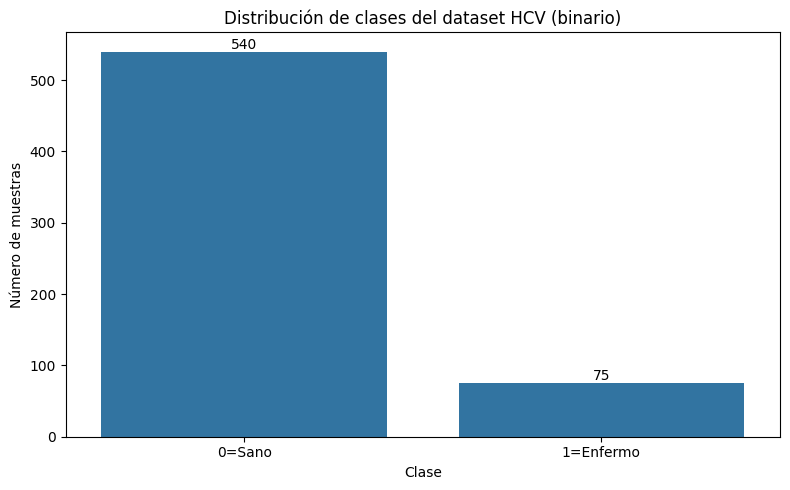

In [5]:
#--- Datos en formato dataframe.
import os
HCV = X.copy()
HCV["Category"] = y_binario

#--- Distribución de clases binaria
conteo_clases = HCV["Category"].value_counts()
porcentaje_clases = (HCV["Category"].value_counts(normalize=True)*100)
tabla_clases = pd.DataFrame({"Frecuencia": conteo_clases,"Porcentaje (%)": porcentaje_clases.round(2)})
tabla_clases.index = [clases_binarias[i] for i in tabla_clases.index]
print("\n----- DISTRIBUCIÓN DE CLASES -----\n")
display(tabla_clases)

os.makedirs("figs", exist_ok=True)
plt.figure(figsize=(8,5))
ax = sns.countplot(data=HCV,x="Category",order=conteo_clases.index)
ax.set_xticklabels([clases_binarias[i] for i in conteo_clases.index])
plt.title("Distribución de clases del dataset HCV (binario)")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f"{int(altura)}",(p.get_x() + p.get_width()/2., altura),ha="center",va="bottom",fontsize=10)
plt.tight_layout()
plt.savefig("figs/bin_dist_clases.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
#--- Valores de faltantes
faltantes = HCV.drop(columns=["Category"]).isnull().sum()
porcentaje_faltantes = (HCV.drop(columns=["Category"]).isnull().mean()*100)
tabla_faltantes = pd.DataFrame({"Valores faltantes": faltantes,"Porcentaje (%)": porcentaje_faltantes.round(2)})
tabla_faltantes = tabla_faltantes.sort_values(by="Porcentaje (%)",ascending=False)
print("\n----- VALORES FALTANTES -----\n")
display(tabla_faltantes)


----- VALORES FALTANTES -----



,Valores faltantes,Porcentaje (%)
ALP,18,2.93
CHOL,10,1.63
ALT,1,0.16
ALB,1,0.16
PROT,1,0.16
Sex,0,0.00
Age,0,0.00
AST,0,0.00
CHE,0,0.00
BIL,0,0.00


In [7]:
#--- Predictores categóricos y numéricos
categoricos = X.select_dtypes(include=["object"]).columns
numericos = X.select_dtypes(exclude=["object"]).columns
print("\nPredictores categóricos:")
print(categoricos)
print("\nPredictores numéricos:")
print(numericos)


Predictores categóricos:
Index(['Sex'], dtype='str')

Predictores numéricos:
Index(['Age', 'ALB', 'ALP', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'CGT', 'PROT',
       'ALT'],
      dtype='str')


C:\Users\Usuario\AppData\Local\Temp\ipykernel_191652\987099044.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricos = X.select_dtypes(include=["object"]).columns


PREPROCESAMIENTO

In [8]:
#--- pipeline para predictores categóricos: aplicamos imputación con la moda y se utiliza codificación one-hot.
transformador_categorico = Pipeline(steps=[("Imputación", SimpleImputer(strategy="most_frequent")),("Codificación", OneHotEncoder(drop="if_binary"))])

#--- pipeline para predictores numéricos: aplicamos imputación con la mediana y se escalan los datos.
transformador_numerico = Pipeline(steps=[("Imputación", SimpleImputer(strategy="median")),("Escalado", StandardScaler())])

#--- preprocesador
preprocesador = ColumnTransformer(transformers=[("categórico", transformador_categorico, categoricos),("numérico", transformador_numerico, numericos)])


TRAIN-TEST SPLIT

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y_binario,test_size=0.2,stratify=y_binario,random_state=98)
print("\nDimensiones conjunto de entrenamiento:", X_train.shape)
print("Dimensiones conjunto de prueba:", X_test.shape)

#--- Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=98)


Dimensiones conjunto de entrenamiento: (492, 12)
Dimensiones conjunto de prueba: (123, 12)


In [10]:
#--- Evualuación de desempeño
def metricas_clasificacion(y_test, y_pred, y_score=None):
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1_pos = f1_score(y_test, y_pred, pos_label=1)
    recall_pos = recall_score(y_test, y_pred, pos_label=1)
    print("Accuracy:", round(acc, 4))
    print("Balanced Accuracy:", round(bal_acc, 4))
    print("F1 Macro:", round(f1, 4))
    print("Precision Macro:", round(precision, 4))
    print("Recall Macro:", round(recall, 4))
    print("F1 clase Enfermo:", round(f1_pos, 4))
    print("Recall clase Enfermo:", round(recall_pos, 4))
    if y_score is not None:
        print("AUC ROC:", round(roc_auc_score(y_test, y_score), 4))

ENTRENAMIENTO DE MODELOS.

1. **Regresión Logística.**

In [11]:
#--- pipeline para regresión logística con SMOTE: 1. preprocesamiento --> 2. SMOTE ---> 3. Regresión Logística
pipeline_logit_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=3)),("classifier", LogisticRegression(max_iter=1000))])

#--- pipeline para regresión logística con ADASYN: 1. preprocesamiento --> 2. ADASYN ---> 3. Regresión Logística
pipeline_logit_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=3)),("classifier", LogisticRegression(max_iter=1000))])

#--- ajuste de hiperparámetros
hp_logit = {"classifier__C": [0.01, 0.1, 1, 10, 100],"classifier__solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"]}
malla_logit_smote = GridSearchCV(estimator=pipeline_logit_smote,param_grid=hp_logit,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_logit_adasyn = GridSearchCV(estimator=pipeline_logit_adasyn,param_grid=hp_logit,scoring="f1_macro",cv=cv,n_jobs=-1)

In [12]:
#--- entrenamiento
malla_logit_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['lbfgs', 'newton-cg', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [13]:
#--- entrenamiento
malla_logit_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__solver': ['lbfgs', 'newton-cg', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

In [14]:
#--- resultados
print("Mejores hiperparámetros Logit con SMOTE:\n")
print(malla_logit_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_logit_smote.best_score_.round(4))

print("\nMejores hiperparámetros Logit con ADASYN:\n")
print(malla_logit_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_logit_adasyn.best_score_.round(4))

Mejores hiperparámetros Logit con SMOTE:

{'classifier__C': 1, 'classifier__solver': 'lbfgs'}

Mejor F1 Macro CV:
0.8771

Mejores hiperparámetros Logit con ADASYN:

{'classifier__C': 0.1, 'classifier__solver': 'lbfgs'}

Mejor F1 Macro CV:
0.8529


In [15]:
#--- predicciones con el mejor modelo en términos de hiperparámetros
y_pred_logit_smote = malla_logit_smote.predict(X_test)
y_pred_logit_adasyn = malla_logit_adasyn.predict(X_test)
y_score_logit_smote = malla_logit_smote.predict_proba(X_test)[:,1]
y_score_logit_adasyn = malla_logit_adasyn.predict_proba(X_test)[:,1]

#--- métricas
print("REPORTE DE CLASIFICACIÓN Logit SMOTE")
print(classification_report(y_test, y_pred_logit_smote, target_names=clases_binarias))
print("REPORTE DE CLASIFICACIÓN Logit ADASYN")
print(classification_report(y_test, y_pred_logit_adasyn, target_names=clases_binarias))

print("MÉTRICAS INDIVIDUALES Logit SMOTE")
metricas_clasificacion(y_test, y_pred_logit_smote, y_score_logit_smote)
print("MÉTRICAS INDIVIDUALES Logit ADASYN")
metricas_clasificacion(y_test, y_pred_logit_adasyn, y_score_logit_adasyn)

REPORTE DE CLASIFICACIÓN Logit SMOTE
              precision    recall  f1-score   support

      0=Sano       0.99      0.97      0.98       108
   1=Enfermo       0.82      0.93      0.88        15

    accuracy                           0.97       123
   macro avg       0.91      0.95      0.93       123
weighted avg       0.97      0.97      0.97       123

REPORTE DE CLASIFICACIÓN Logit ADASYN
              precision    recall  f1-score   support

      0=Sano       1.00      0.96      0.98       108
   1=Enfermo       0.79      1.00      0.88        15

    accuracy                           0.97       123
   macro avg       0.89      0.98      0.93       123
weighted avg       0.97      0.97      0.97       123

MÉTRICAS INDIVIDUALES Logit SMOTE
Accuracy: 0.9675
Balanced Accuracy: 0.9528
F1 Macro: 0.9282
Precision Macro: 0.907
Recall Macro: 0.9528
F1 clase Enfermo: 0.875
Recall clase Enfermo: 0.9333
AUC ROC: 0.9957
MÉTRICAS INDIVIDUALES Logit ADASYN
Accuracy: 0.9675
Balanced Acc

2. **K-Vecinos Más Cercanos (k-NN Classification).**

In [16]:
#--- pipeline para kNN con SMOTE: 1. preprocesamiento --> 2. SMOTE ---> 3. kNN classification
pipeline_knn_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=3)),("classifier", KNeighborsClassifier())])

#--- pipeline para kNN con ADASYN: 1. preprocesamiento --> 2. ADASYN ---> 3. kNN classification
pipeline_knn_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=3)),("classifier", KNeighborsClassifier())])

#--- ajuste de hiperparámetros
hp_knn = {"classifier__n_neighbors": [3,5,7,9,11],"classifier__weights": ["uniform", "distance"]}
malla_knn_smote = GridSearchCV(estimator=pipeline_knn_smote,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_knn_adasyn = GridSearchCV(estimator=pipeline_knn_adasyn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

In [17]:
#--- entrenamiento
malla_knn_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_neighbors': [3, 5, ...], 'classifier__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [18]:
#--- entrenamiento
malla_knn_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_neighbors': [3, 5, ...], 'classifier__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [19]:
#--- resultados
print("Mejores hiperparámetros k-NN con SMOTE:\n")
print(malla_knn_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_knn_smote.best_score_.round(4))

print("\nMejores hiperparámetros k-NN con ADASYN:\n")
print(malla_knn_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_knn_adasyn.best_score_.round(4))

Mejores hiperparámetros k-NN con SMOTE:

{'classifier__n_neighbors': 3, 'classifier__weights': 'uniform'}

Mejor F1 Macro CV:
0.8331

Mejores hiperparámetros k-NN con ADASYN:

{'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}

Mejor F1 Macro CV:
0.8269


In [20]:
#--- predicciones con el mejor modelo en términos de hiperparámetros
y_pred_knn_smote = malla_knn_smote.predict(X_test)
y_pred_knn_adasyn = malla_knn_adasyn.predict(X_test)
y_score_knn_smote = malla_knn_smote.predict_proba(X_test)[:,1]
y_score_knn_adasyn = malla_knn_adasyn.predict_proba(X_test)[:,1]

#--- métricas
print("REPORTE DE CLASIFICACIÓN k-NN SMOTE")
print(classification_report(y_test, y_pred_knn_smote, target_names=clases_binarias))
print("REPORTE DE CLASIFICACIÓN k-NN ADASYN")
print(classification_report(y_test, y_pred_knn_adasyn, target_names=clases_binarias))

print("MÉTRICAS INDIVIDUALES k-NN SMOTE")
metricas_clasificacion(y_test, y_pred_knn_smote, y_score_knn_smote)
print("MÉTRICAS INDIVIDUALES k-NN ADASYN")
metricas_clasificacion(y_test, y_pred_knn_adasyn, y_score_knn_adasyn)

REPORTE DE CLASIFICACIÓN k-NN SMOTE
              precision    recall  f1-score   support

      0=Sano       1.00      0.97      0.99       108
   1=Enfermo       0.83      1.00      0.91        15

    accuracy                           0.98       123
   macro avg       0.92      0.99      0.95       123
weighted avg       0.98      0.98      0.98       123

REPORTE DE CLASIFICACIÓN k-NN ADASYN
              precision    recall  f1-score   support

      0=Sano       1.00      0.95      0.98       108
   1=Enfermo       0.75      1.00      0.86        15

    accuracy                           0.96       123
   macro avg       0.88      0.98      0.92       123
weighted avg       0.97      0.96      0.96       123

MÉTRICAS INDIVIDUALES k-NN SMOTE
Accuracy: 0.9756
Balanced Accuracy: 0.9861
F1 Macro: 0.9475
Precision Macro: 0.9167
Recall Macro: 0.9861
F1 clase Enfermo: 0.9091
Recall clase Enfermo: 1.0
AUC ROC: 0.9917
MÉTRICAS INDIVIDUALES k-NN ADASYN
Accuracy: 0.9593
Balanced Accuracy

3. **Bosque Aleatorio.**

In [21]:
#--- pipeline para random forest con SMOTE: 1. preprocesamiento --> 2. SMOTE ---> 3. Random Forest classification
pipeline_rf_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=3)),("classifier", RandomForestClassifier(random_state=98))])

#--- pipeline para random forest con ADASYN: 1. preprocesamiento --> 2. ADASYN ---> 3. Random Forest classification
pipeline_rf_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=3)),("classifier", RandomForestClassifier(random_state=98))])

#--- ajuste de hiperparámetros
hp_rf = {"classifier__n_estimators": [10,50,100,200,500],"classifier__max_depth": [3,5,7,9,11],"classifier__min_samples_leaf": [1,2,5,10,20]}
malla_rf_smote = GridSearchCV(estimator=pipeline_rf_smote,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_rf_adasyn = GridSearchCV(estimator=pipeline_rf_adasyn,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

In [22]:
#--- entrenamiento
malla_rf_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [23]:
#--- entrenamiento
malla_rf_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [3, 5, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [24]:
#--- resultados
print("Mejores hiperparámetros Random Forest con SMOTE:\n")
print(malla_rf_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_rf_smote.best_score_.round(4))

print("\nMejores hiperparámetros Random Forest con ADASYN:\n")
print(malla_rf_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_rf_adasyn.best_score_.round(4))

Mejores hiperparámetros Random Forest con SMOTE:

{'classifier__max_depth': 11, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}

Mejor F1 Macro CV:
0.9359

Mejores hiperparámetros Random Forest con ADASYN:

{'classifier__max_depth': 11, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 100}

Mejor F1 Macro CV:
0.9354


In [25]:
#--- predicciones con el mejor modelo en términos de hiperparámetros
y_pred_rf_smote = malla_rf_smote.predict(X_test)
y_pred_rf_adasyn = malla_rf_adasyn.predict(X_test)
y_score_rf_smote = malla_rf_smote.predict_proba(X_test)[:,1]
y_score_rf_adasyn = malla_rf_adasyn.predict_proba(X_test)[:,1]

#--- métricas
print("REPORTE DE CLASIFICACIÓN Random Forest SMOTE")
print(classification_report(y_test, y_pred_rf_smote, target_names=clases_binarias))
print("REPORTE DE CLASIFICACIÓN Random Forest ADASYN")
print(classification_report(y_test, y_pred_rf_adasyn, target_names=clases_binarias))

print("MÉTRICAS INDIVIDUALES Random Forest SMOTE")
metricas_clasificacion(y_test, y_pred_rf_smote, y_score_rf_smote)
print("MÉTRICAS INDIVIDUALES Random Forest ADASYN")
metricas_clasificacion(y_test, y_pred_rf_adasyn, y_score_rf_adasyn)

REPORTE DE CLASIFICACIÓN Random Forest SMOTE
              precision    recall  f1-score   support

      0=Sano       0.99      0.98      0.99       108
   1=Enfermo       0.88      0.93      0.90        15

    accuracy                           0.98       123
   macro avg       0.93      0.96      0.94       123
weighted avg       0.98      0.98      0.98       123

REPORTE DE CLASIFICACIÓN Random Forest ADASYN
              precision    recall  f1-score   support

      0=Sano       0.99      0.98      0.99       108
   1=Enfermo       0.88      0.93      0.90        15

    accuracy                           0.98       123
   macro avg       0.93      0.96      0.94       123
weighted avg       0.98      0.98      0.98       123

MÉTRICAS INDIVIDUALES Random Forest SMOTE
Accuracy: 0.9756
Balanced Accuracy: 0.9574
F1 Macro: 0.9446
Precision Macro: 0.9328
Recall Macro: 0.9574
F1 clase Enfermo: 0.9032
Recall clase Enfermo: 0.9333
AUC ROC: 0.9957
MÉTRICAS INDIVIDUALES Random Forest AD

4. **Máquina de Vectores de Soporte (SVM).**

In [26]:
#--- pipeline para SVC con SMOTE: 1. preprocesamiento --> 2. SMOTE ---> 3. SVC
pipeline_svc_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=3)),("classifier", SVC(probability=True,random_state=98))])

#--- pipeline para SVC con ADASYN: 1. preprocesamiento --> 2. ADASYN ---> 3. SVC
pipeline_svc_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=3)),("classifier", SVC(probability=True,random_state=98))])

#--- ajuste de hiperparámetros
hp_svm = {"classifier__C": [0.01, 0.1, 1, 10, 100], "classifier__kernel": ["linear", "poly", "rbf", "sigmoid"], "classifier__gamma": ["scale", "auto"]}
malla_svc_smote = GridSearchCV(estimator=pipeline_svc_smote,param_grid=hp_svm,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_svc_adasyn = GridSearchCV(estimator=pipeline_svc_adasyn,param_grid=hp_svm,scoring="f1_macro",cv=cv,n_jobs=-1)

In [27]:
#--- entrenamiento
malla_svc_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__gamma': ['scale', 'auto'], 'classifier__kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [28]:
#--- entrenamiento
malla_svc_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__gamma': ['scale', 'auto'], 'classifier__kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [29]:
#--- resultados
print("Mejores hiperparámetros SVC con SMOTE:\n")
print(malla_svc_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_svc_smote.best_score_.round(4))

print("\nMejores hiperparámetros SVC con ADASYN:\n")
print(malla_svc_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_svc_adasyn.best_score_.round(4))

Mejores hiperparámetros SVC con SMOTE:

{'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}

Mejor F1 Macro CV:
0.9025

Mejores hiperparámetros SVC con ADASYN:

{'classifier__C': 1, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}

Mejor F1 Macro CV:
0.8944


In [30]:
#--- predicciones con el mejor modelo en términos de hiperparámetros
y_pred_svc_smote = malla_svc_smote.predict(X_test)
y_pred_svc_adasyn = malla_svc_adasyn.predict(X_test)
y_score_svc_smote = malla_svc_smote.predict_proba(X_test)[:,1]
y_score_svc_adasyn = malla_svc_adasyn.predict_proba(X_test)[:,1]

#--- métricas
print("REPORTE DE CLASIFICACIÓN SVC SMOTE")
print(classification_report(y_test, y_pred_svc_smote, target_names=clases_binarias))
print("REPORTE DE CLASIFICACIÓN SVC ADASYN")
print(classification_report(y_test, y_pred_svc_adasyn, target_names=clases_binarias))

print("MÉTRICAS INDIVIDUALES SVC SMOTE")
metricas_clasificacion(y_test, y_pred_svc_smote, y_score_svc_smote)
print("MÉTRICAS INDIVIDUALES SVC ADASYN")
metricas_clasificacion(y_test, y_pred_svc_adasyn, y_score_svc_adasyn)

REPORTE DE CLASIFICACIÓN SVC SMOTE
              precision    recall  f1-score   support

      0=Sano       0.99      0.96      0.98       108
   1=Enfermo       0.78      0.93      0.85        15

    accuracy                           0.96       123
   macro avg       0.88      0.95      0.91       123
weighted avg       0.96      0.96      0.96       123

REPORTE DE CLASIFICACIÓN SVC ADASYN
              precision    recall  f1-score   support

      0=Sano       1.00      0.96      0.98       108
   1=Enfermo       0.79      1.00      0.88        15

    accuracy                           0.97       123
   macro avg       0.89      0.98      0.93       123
weighted avg       0.97      0.97      0.97       123

MÉTRICAS INDIVIDUALES SVC SMOTE
Accuracy: 0.9593
Balanced Accuracy: 0.9481
F1 Macro: 0.9125
Precision Macro: 0.8841
Recall Macro: 0.9481
F1 clase Enfermo: 0.8485
Recall clase Enfermo: 0.9333
AUC ROC: 0.9957
MÉTRICAS INDIVIDUALES SVC ADASYN
Accuracy: 0.9675
Balanced Accuracy:

5. **Perceptrón Multicapa (MLP).**

In [31]:
#--- pipeline para MLP con SMOTE: 1. preprocesamiento --> 2. SMOTE ---> 3. MLP Classification
pipeline_mlp_smote = ImbPipeline(steps=
 [("preprocessor", preprocesador),("smote", SMOTE(random_state=98,k_neighbors=3)),("classifier", MLPClassifier(max_iter=1000,random_state=98))])

#--- pipeline para MLP con ADASYN: 1. preprocesamiento --> 2. ADASYN ---> 3. MLP Classification
pipeline_mlp_adasyn = ImbPipeline(steps=
 [("preprocessor", preprocesador),("adasyn", ADASYN(random_state=98,n_neighbors=3)),("classifier", MLPClassifier(max_iter=1000,random_state=98))])

#--- ajuste de hiperparámetros
hp_ann = {"classifier__hidden_layer_sizes": [(10,),(20,),(30,),(40,),(50,)],"classifier__activation": ["identity", "logistic", "tanh", "relu"], "classifier__alpha": [0.0001, 0.001, 0.01, 0.1, 1]}
malla_mlp_smote = GridSearchCV(estimator=pipeline_mlp_smote,param_grid=hp_ann,scoring="f1_macro",cv=cv,n_jobs=-1)
malla_mlp_adasyn = GridSearchCV(estimator=pipeline_mlp_adasyn,param_grid=hp_ann,scoring="f1_macro",cv=cv,n_jobs=-1)

In [32]:
#--- entrenamiento
malla_mlp_smote.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__activation': ['identity', 'logistic', ...], 'classifier__alpha': [0.0001, 0.001, ...], 'classifier__hidden_layer_sizes': [(10,), (20,), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mo

In [33]:
#--- entrenamiento
malla_mlp_adasyn.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=98))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__activation': ['identity', 'logistic', ...], 'classifier__alpha': [0.0001, 0.001, ...], 'classifier__hidden_layer_sizes': [(10,), (20,), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the mo

In [34]:
#--- resultados
print("Mejores hiperparámetros MLP con SMOTE:\n")
print(malla_mlp_smote.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_mlp_smote.best_score_.round(4))

print("\nMejores hiperparámetros MLP con ADASYN:\n")
print(malla_mlp_adasyn.best_params_)
print("\nMejor F1 Macro CV:")
print(malla_mlp_adasyn.best_score_.round(4))

Mejores hiperparámetros MLP con SMOTE:

{'classifier__activation': 'relu', 'classifier__alpha': 1, 'classifier__hidden_layer_sizes': (30,)}

Mejor F1 Macro CV:
0.8994

Mejores hiperparámetros MLP con ADASYN:

{'classifier__activation': 'relu', 'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': (10,)}

Mejor F1 Macro CV:
0.8979


In [35]:
#--- predicciones con el mejor modelo en términos de hiperparámetros
y_pred_mlp_smote = malla_mlp_smote.predict(X_test)
y_pred_mlp_adasyn = malla_mlp_adasyn.predict(X_test)
y_score_mlp_smote = malla_mlp_smote.predict_proba(X_test)[:,1]
y_score_mlp_adasyn = malla_mlp_adasyn.predict_proba(X_test)[:,1]

#--- métricas
print("REPORTE DE CLASIFICACIÓN MLP SMOTE")
print(classification_report(y_test, y_pred_mlp_smote, target_names=clases_binarias))
print("REPORTE DE CLASIFICACIÓN MLP ADASYN")
print(classification_report(y_test, y_pred_mlp_adasyn, target_names=clases_binarias))

print("MÉTRICAS INDIVIDUALES MLP SMOTE")
metricas_clasificacion(y_test, y_pred_mlp_smote, y_score_mlp_smote)
print("MÉTRICAS INDIVIDUALES MLP ADASYN")
metricas_clasificacion(y_test, y_pred_mlp_adasyn, y_score_mlp_adasyn)

REPORTE DE CLASIFICACIÓN MLP SMOTE
              precision    recall  f1-score   support

      0=Sano       0.99      0.97      0.98       108
   1=Enfermo       0.82      0.93      0.88        15

    accuracy                           0.97       123
   macro avg       0.91      0.95      0.93       123
weighted avg       0.97      0.97      0.97       123

REPORTE DE CLASIFICACIÓN MLP ADASYN
              precision    recall  f1-score   support

      0=Sano       1.00      0.96      0.98       108
   1=Enfermo       0.79      1.00      0.88        15

    accuracy                           0.97       123
   macro avg       0.89      0.98      0.93       123
weighted avg       0.97      0.97      0.97       123

MÉTRICAS INDIVIDUALES MLP SMOTE
Accuracy: 0.9675
Balanced Accuracy: 0.9528
F1 Macro: 0.9282
Precision Macro: 0.907
Recall Macro: 0.9528
F1 clase Enfermo: 0.875
Recall clase Enfermo: 0.9333
AUC ROC: 0.9969
MÉTRICAS INDIVIDUALES MLP ADASYN
Accuracy: 0.9675
Balanced Accuracy: 0

SELECCIÓN Y EXTRACCIÓN DE CARACTERÍSTICAS

1. **Análisis individual de predictores**

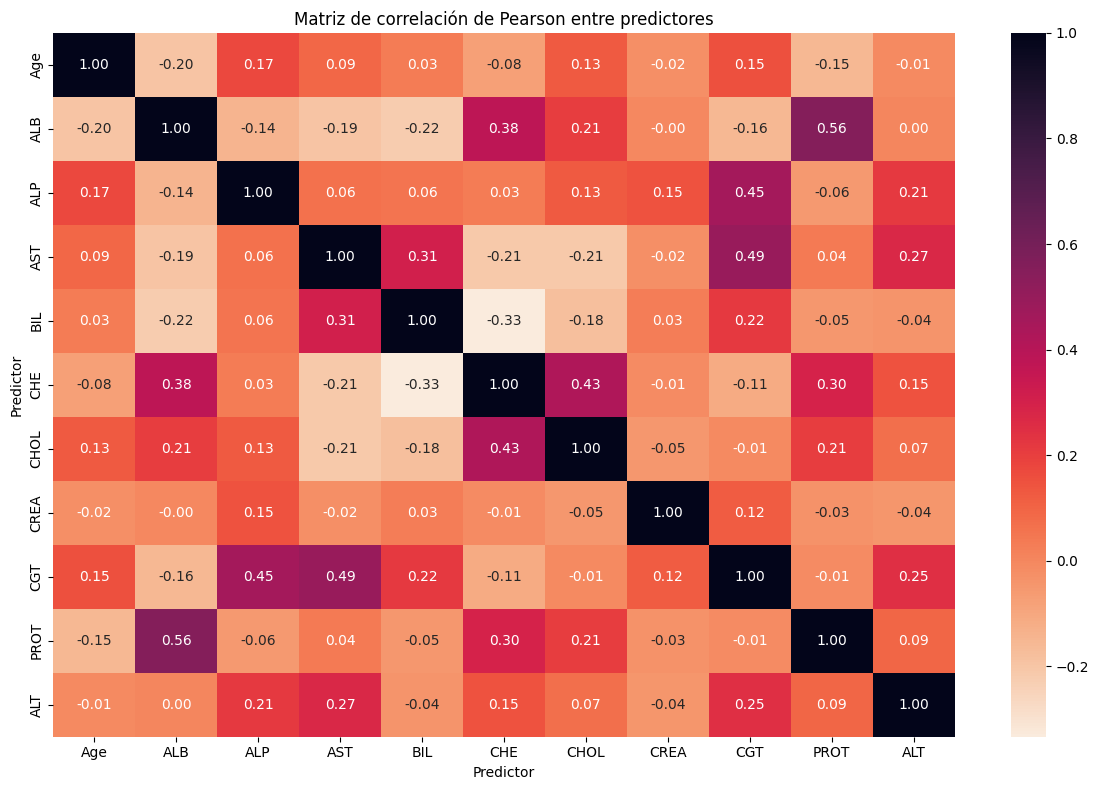

In [36]:
#--- Correlación (lineal) de Pearson entre predictores numéricos
import os
os.makedirs("figs", exist_ok=True)
correl = X.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(correl,cmap="rocket_r",annot=True,fmt=".2f")
plt.title("Matriz de correlación de Pearson entre predictores")
plt.xlabel("Predictor")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig("figs/bin_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()


   Predictor  Informacion_Mutua
3        AST               0.19
4        BIL               0.13
2        ALP               0.12
10       ALT               0.11
1        ALB               0.11
7       CREA               0.09
8        CGT               0.08
5        CHE               0.07
6       CHOL               0.05
0        Age               0.03
9       PROT               0.03


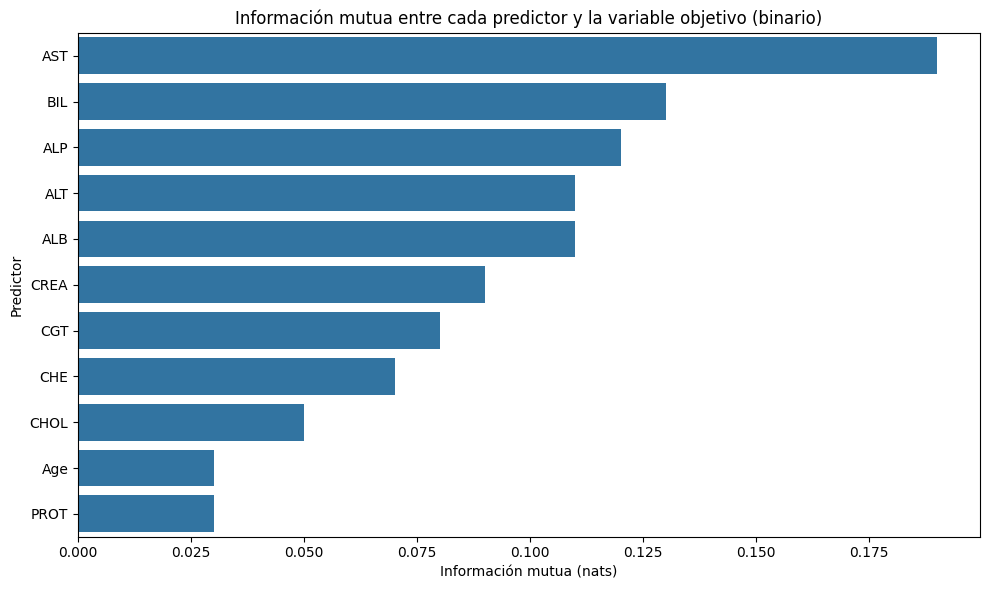

In [37]:
#--- Información mutua de cada predictor respecto a la variable objetivo (binario).
import os
os.makedirs("figs", exist_ok=True)
imputacion = Pipeline(steps=[("imputacion", SimpleImputer(strategy="median"))])
X_imp = imputacion.fit_transform(X_train[numericos])
X_imp = pd.DataFrame(X_imp,columns=numericos)

info_mutua = mutual_info_classif(X_imp,y_train,random_state=98)
info_mutua = np.round(info_mutua,2)
info_mutua_df = pd.DataFrame({"Predictor": X_imp.columns,"Informacion_Mutua": info_mutua})
info_mutua_df = info_mutua_df.sort_values(by="Informacion_Mutua",ascending=False)
print(info_mutua_df)

plt.figure(figsize=(10,6))
sns.barplot(data=info_mutua_df,x="Informacion_Mutua",y="Predictor")
plt.title("Información mutua entre cada predictor y la variable objetivo (binario)")
plt.xlabel("Información mutua (nats)")
plt.ylabel("Predictor")
plt.tight_layout()
plt.savefig("figs/bin_info_mutua.png", dpi=150, bbox_inches="tight")
plt.show()


2. **Extracción lineal de características mediante PCA.**

Los dos mejores modelos de acuerdo al F1-score macro en test se reentrenan dentro de un pipeline con PCA. Se aplica GridSearchCV completo porque los hiperparámetros óptimos del clasificador cambian al añadir reducción de dimensionalidad.

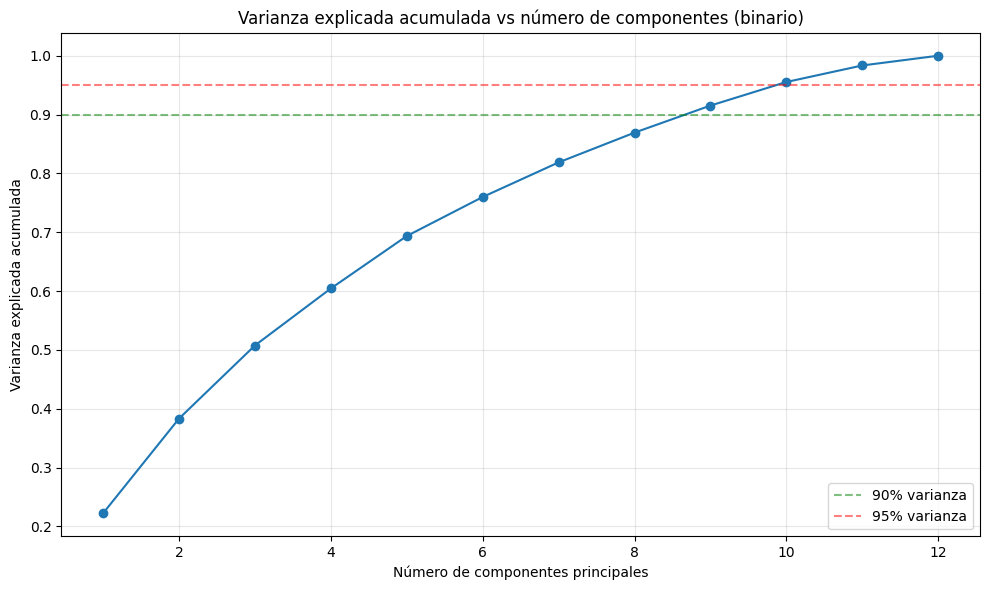

Número de componentes para explicar el 90% de la varianza: 9
Número de componentes para explicar el 95% de la varianza: 10


In [38]:
#--- Varianza explicada acumulada vs número de componentes principales.
import os
os.makedirs("figs", exist_ok=True)
X_train_pre = preprocesador.fit_transform(X_train)
pca_completo = PCA()
pca_completo.fit(X_train_pre)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

plt.figure(figsize=(10,6))
plt.plot(np.arange(1, len(varianza_acumulada)+1), varianza_acumulada, marker="o")
plt.axhline(0.90, color="green", linestyle="--", alpha=0.5, label="90% varianza")
plt.axhline(0.95, color="red", linestyle="--", alpha=0.5, label="95% varianza")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada vs número de componentes (binario)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/bin_pca_varianza.png", dpi=150, bbox_inches="tight")
plt.show()

var_90 = np.where(varianza_acumulada >= 0.9)[0][0] + 1
print("Número de componentes para explicar el 90% de la varianza:", var_90)
var_95 = np.where(varianza_acumulada >= 0.95)[0][0] + 1
print("Número de componentes para explicar el 95% de la varianza:", var_95)


In [39]:
#--- pipeline para PCA (90% de varianza) + RF + SMOTE: 1. preprocesamiento --> 2. PCA --> 3. SMOTE ---> 4. RF Classification
pipeline_pca90_rf = ImbPipeline([
    ("preprocessor", preprocesador),("pca 90% variance", PCA(n_components=0.9)),("smote", SMOTE(random_state=98,k_neighbors=3)),
    ("classifier", RandomForestClassifier(random_state=98))])
malla_pca90_rf = GridSearchCV(estimator=pipeline_pca90_rf,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

#--- pipeline para PCA (95% de varianza) + RF + SMOTE: 1. preprocesamiento --> 2. PCA --> 3. SMOTE ---> 4. RF Classification
pipeline_pca95_rf = ImbPipeline([
    ("preprocessor", preprocesador),("pca 95% variance", PCA(n_components=0.95)),("smote", SMOTE(random_state=98,k_neighbors=3)),
    ("classifier", RandomForestClassifier(random_state=98))])
malla_pca95_rf = GridSearchCV(estimator=pipeline_pca95_rf,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

In [40]:
#--- pipeline para PCA (90% de varianza) + k-NN + ADASYN: 1. preprocesamiento --> 2. PCA --> 3. ADASYN ---> 4. k-NN Classification
pipeline_pca90_knn = ImbPipeline([
    ("preprocessor", preprocesador),("pca 90% variance", PCA(n_components=0.9)),("adasyn", ADASYN(random_state=98,n_neighbors=3)),
    ("classifier", KNeighborsClassifier())])
malla_pca90_knn = GridSearchCV(estimator=pipeline_pca90_knn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

#--- pipeline para PCA (95% de varianza) + k-NN + ADASYN: 1. preprocesamiento --> 2. PCA --> 3. ADASYN ---> 4. k-NN Classification
pipeline_pca95_knn = ImbPipeline([
    ("preprocessor", preprocesador),("pca 95% variance", PCA(n_components=0.95)),("adasyn", ADASYN(random_state=98,n_neighbors=3)),
    ("classifier", KNeighborsClassifier())])
malla_pca95_knn = GridSearchCV(estimator=pipeline_pca95_knn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

In [41]:
#--- entrenamiento
malla_pca90_rf.fit(X_train, y_train)
malla_pca95_rf.fit(X_train, y_train)
#--- predicción
y_pred_pca90_rf = malla_pca90_rf.predict(X_test)
y_pred_pca95_rf = malla_pca95_rf.predict(X_test)
#--- métricas
print("REPORTE DE CLASIFICACIÓN PCA_90 RF SMOTE")
print(classification_report(y_test, y_pred_pca90_rf, target_names=clases_binarias))
print("REPORTE DE CLASIFICACIÓN PCA_95 RF SMOTE")
print(classification_report(y_test, y_pred_pca95_rf, target_names=clases_binarias))
print("MÉTRICAS INDIVIDUALES PCA_90 RF SMOTE")
metricas_clasificacion(y_test, y_pred_pca90_rf)
print("MÉTRICAS INDIVIDUALES PCA_95 RF SMOTE")
metricas_clasificacion(y_test, y_pred_pca95_rf)

REPORTE DE CLASIFICACIÓN PCA_90 RF SMOTE
              precision    recall  f1-score   support

      0=Sano       0.98      0.98      0.98       108
   1=Enfermo       0.87      0.87      0.87        15

    accuracy                           0.97       123
   macro avg       0.92      0.92      0.92       123
weighted avg       0.97      0.97      0.97       123

REPORTE DE CLASIFICACIÓN PCA_95 RF SMOTE
              precision    recall  f1-score   support

      0=Sano       0.98      0.96      0.97       108
   1=Enfermo       0.76      0.87      0.81        15

    accuracy                           0.95       123
   macro avg       0.87      0.91      0.89       123
weighted avg       0.95      0.95      0.95       123

MÉTRICAS INDIVIDUALES PCA_90 RF SMOTE
Accuracy: 0.9675
Balanced Accuracy: 0.9241
F1 Macro: 0.9241
Precision Macro: 0.9241
Recall Macro: 0.9241
F1 clase Enfermo: 0.8667
Recall clase Enfermo: 0.8667
MÉTRICAS INDIVIDUALES PCA_95 RF SMOTE
Accuracy: 0.9512
Balanced Acc

In [42]:
#--- entrenamiento
malla_pca90_knn.fit(X_train, y_train)
malla_pca95_knn.fit(X_train, y_train)
#--- predicción
y_pred_pca90_knn = malla_pca90_knn.predict(X_test)
y_pred_pca95_knn = malla_pca95_knn.predict(X_test)
#--- métricas
print("REPORTE DE CLASIFICACIÓN PCA_90 k-NN ADASYN")
print(classification_report(y_test, y_pred_pca90_knn, target_names=clases_binarias))
print("REPORTE DE CLASIFICACIÓN PCA_95 k-NN ADASYN")
print(classification_report(y_test, y_pred_pca95_knn, target_names=clases_binarias))
print("MÉTRICAS INDIVIDUALES PCA_90 k-NN ADASYN")
metricas_clasificacion(y_test, y_pred_pca90_knn)
print("MÉTRICAS INDIVIDUALES PCA_95 k-NN ADASYN")
metricas_clasificacion(y_test, y_pred_pca95_knn)

REPORTE DE CLASIFICACIÓN PCA_90 k-NN ADASYN
              precision    recall  f1-score   support

      0=Sano       1.00      0.93      0.96       108
   1=Enfermo       0.65      1.00      0.79        15

    accuracy                           0.93       123
   macro avg       0.83      0.96      0.88       123
weighted avg       0.96      0.93      0.94       123

REPORTE DE CLASIFICACIÓN PCA_95 k-NN ADASYN
              precision    recall  f1-score   support

      0=Sano       1.00      0.96      0.98       108
   1=Enfermo       0.79      1.00      0.88        15

    accuracy                           0.97       123
   macro avg       0.89      0.98      0.93       123
weighted avg       0.97      0.97      0.97       123

MÉTRICAS INDIVIDUALES PCA_90 k-NN ADASYN
Accuracy: 0.935
Balanced Accuracy: 0.963
F1 Macro: 0.8755
Precision Macro: 0.8261
Recall Macro: 0.963
F1 clase Enfermo: 0.7895
Recall clase Enfermo: 1.0
MÉTRICAS INDIVIDUALES PCA_95 k-NN ADASYN
Accuracy: 0.9675
Balanc

3. **Extracción no lineal de características mediante UMAP.**

In [43]:
#--- pipeline para UMAP 8c + RF + SMOTE: 1. preprocesamiento --> 2. UMAP --> 3. SMOTE ---> 4. RF Classification
pipeline_umap8_rf = ImbPipeline([
    ("preprocessor", preprocesador),("umap", umap.UMAP(n_components=8,n_neighbors=15,min_dist=0.1,random_state=98)),("smote", SMOTE(random_state=98,k_neighbors=3)),
    ("classifier", RandomForestClassifier(random_state=98))])
malla_umap8_rf = GridSearchCV(estimator=pipeline_umap8_rf,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

#--- pipeline para UMAP 9c + RF + SMOTE: 1. preprocesamiento --> 2. UMAP --> 3. SMOTE ---> 4. RF Classification
pipeline_umap9_rf = ImbPipeline([
    ("preprocessor", preprocesador),("umap", umap.UMAP(n_components=9,n_neighbors=15,min_dist=0.1,random_state=98)),("smote", SMOTE(random_state=98,k_neighbors=3)),
    ("classifier", RandomForestClassifier(random_state=98))])
malla_umap9_rf = GridSearchCV(estimator=pipeline_umap9_rf,param_grid=hp_rf,scoring="f1_macro",cv=cv,n_jobs=-1)

UMAP no funciona bien con ADASYN entonces para experimentar utilicé SMOTE.

In [44]:
#--- pipeline para UMAP 8c + k-NN + SMOTE: 1. preprocesamiento --> 2. UMAP --> 3. SMOTE ---> 4. k-NN Classification
pipeline_umap8_knn = ImbPipeline([
    ("preprocessor", preprocesador),("umap", umap.UMAP(n_components=8,n_neighbors=15,min_dist=0.1,random_state=98)),("smote", SMOTE(random_state=98,k_neighbors=3)),
    ("classifier", KNeighborsClassifier())])
malla_umap8_knn = GridSearchCV(estimator=pipeline_umap8_knn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

#--- pipeline para UMAP 9c + k-NN + SMOTE: 1. preprocesamiento --> 2. UMAP --> 3. SMOTE ---> 4. k-NN Classification
pipeline_umap9_knn = ImbPipeline([
    ("preprocessor", preprocesador),("umap", umap.UMAP(n_components=9,n_neighbors=15,min_dist=0.1,random_state=98)),("smote", SMOTE(random_state=98,k_neighbors=3)),
    ("classifier", KNeighborsClassifier())])
malla_umap9_knn = GridSearchCV(estimator=pipeline_umap9_knn,param_grid=hp_knn,scoring="f1_macro",cv=cv,n_jobs=-1)

In [45]:
#--- entrenamiento
malla_umap8_rf.fit(X_train, y_train)
malla_umap9_rf.fit(X_train, y_train)
#--- predicción
y_pred_umap8_rf = malla_umap8_rf.predict(X_test)
y_pred_umap9_rf = malla_umap9_rf.predict(X_test)
#--- métricas
print("REPORTE DE CLASIFICACIÓN UMAP 8C RF SMOTE")
print(classification_report(y_test, y_pred_umap8_rf, target_names=clases_binarias))
print("REPORTE DE CLASIFICACIÓN UMAP 9C RF SMOTE")
print(classification_report(y_test, y_pred_umap9_rf, target_names=clases_binarias))
print("MÉTRICAS INDIVIDUALES UMAP 8C RF SMOTE")
metricas_clasificacion(y_test, y_pred_umap8_rf)
print("MÉTRICAS INDIVIDUALES UMAP 9C RF SMOTE")
metricas_clasificacion(y_test, y_pred_umap9_rf)

c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


REPORTE DE CLASIFICACIÓN UMAP 8C RF SMOTE
              precision    recall  f1-score   support

      0=Sano       0.91      0.99      0.95       108
   1=Enfermo       0.80      0.27      0.40        15

    accuracy                           0.90       123
   macro avg       0.85      0.63      0.67       123
weighted avg       0.89      0.90      0.88       123

REPORTE DE CLASIFICACIÓN UMAP 9C RF SMOTE
              precision    recall  f1-score   support

      0=Sano       0.92      0.98      0.95       108
   1=Enfermo       0.75      0.40      0.52        15

    accuracy                           0.91       123
   macro avg       0.84      0.69      0.74       123
weighted avg       0.90      0.91      0.90       123

MÉTRICAS INDIVIDUALES UMAP 8C RF SMOTE
Accuracy: 0.9024
Balanced Accuracy: 0.6287
F1 Macro: 0.6735
Precision Macro: 0.8534
Recall Macro: 0.6287
F1 clase Enfermo: 0.4
Recall clase Enfermo: 0.2667
MÉTRICAS INDIVIDUALES UMAP 9C RF SMOTE
Accuracy: 0.9106
Balanced Ac

In [46]:
#--- entrenamiento
malla_umap8_knn.fit(X_train, y_train)
malla_umap9_knn.fit(X_train, y_train)
#--- predicción
y_pred_umap8_knn = malla_umap8_knn.predict(X_test)
y_pred_umap9_knn = malla_umap9_knn.predict(X_test)
#--- métricas
print("REPORTE DE CLASIFICACIÓN UMAP 8C k-NN SMOTE")
print(classification_report(y_test, y_pred_umap8_knn, target_names=clases_binarias))
print("REPORTE DE CLASIFICACIÓN UMAP 9C k-NN SMOTE")
print(classification_report(y_test, y_pred_umap9_knn, target_names=clases_binarias))
print("MÉTRICAS INDIVIDUALES UMAP 8C k-NN SMOTE")
metricas_clasificacion(y_test, y_pred_umap8_knn)
print("MÉTRICAS INDIVIDUALES UMAP 9C k-NN SMOTE")
metricas_clasificacion(y_test, y_pred_umap9_knn)

c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Usuario\Documents\TrabajoFinalModelos2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


REPORTE DE CLASIFICACIÓN UMAP 8C k-NN SMOTE
              precision    recall  f1-score   support

      0=Sano       0.91      0.99      0.95       108
   1=Enfermo       0.80      0.27      0.40        15

    accuracy                           0.90       123
   macro avg       0.85      0.63      0.67       123
weighted avg       0.89      0.90      0.88       123

REPORTE DE CLASIFICACIÓN UMAP 9C k-NN SMOTE
              precision    recall  f1-score   support

      0=Sano       0.91      0.99      0.95       108
   1=Enfermo       0.80      0.27      0.40        15

    accuracy                           0.90       123
   macro avg       0.85      0.63      0.67       123
weighted avg       0.89      0.90      0.88       123

MÉTRICAS INDIVIDUALES UMAP 8C k-NN SMOTE
Accuracy: 0.9024
Balanced Accuracy: 0.6287
F1 Macro: 0.6735
Precision Macro: 0.8534
Recall Macro: 0.6287
F1 clase Enfermo: 0.4
Recall clase Enfermo: 0.2667
MÉTRICAS INDIVIDUALES UMAP 9C k-NN SMOTE
Accuracy: 0.9024
Bal

### TABLA COMPARATIVA Y DIAGNÓSTICO DE SOBREAJUSTE


In [47]:
#--- Recopilación de todos los modelos (base + PCA + UMAP) para comparación final.
modelos = {
    "Logit SMOTE":      malla_logit_smote,
    "Logit ADASYN":     malla_logit_adasyn,
    "k-NN SMOTE":       malla_knn_smote,
    "k-NN ADASYN":      malla_knn_adasyn,
    "RF SMOTE":         malla_rf_smote,
    "RF ADASYN":        malla_rf_adasyn,
    "SVC SMOTE":        malla_svc_smote,
    "SVC ADASYN":       malla_svc_adasyn,
    "MLP SMOTE":        malla_mlp_smote,
    "MLP ADASYN":       malla_mlp_adasyn,
    "PCA90 RF SMOTE":   malla_pca90_rf,
    "PCA95 RF SMOTE":   malla_pca95_rf,
    "PCA90 k-NN ADASYN":malla_pca90_knn,
    "PCA95 k-NN ADASYN":malla_pca95_knn,
    "UMAP8 RF SMOTE":   malla_umap8_rf,
    "UMAP9 RF SMOTE":   malla_umap9_rf,
    "UMAP8 k-NN SMOTE": malla_umap8_knn,
    "UMAP9 k-NN SMOTE": malla_umap9_knn,
}

filas = []
for nombre, m in modelos.items():
    yp_tr = m.predict(X_train)
    yp_te = m.predict(X_test)
    f1_tr = f1_score(y_train, yp_tr, average="macro", zero_division=0)
    f1_te = f1_score(y_test,  yp_te, average="macro", zero_division=0)
    ba_te = balanced_accuracy_score(y_test, yp_te)
    acc_te = accuracy_score(y_test, yp_te)
    f1_pos = f1_score(y_test, yp_te, pos_label=1, zero_division=0)
    try:
        ys_te = m.predict_proba(X_test)[:, 1]
        auc_val = roc_auc_score(y_test, ys_te)
    except Exception:
        auc_val = np.nan
    filas.append({
        "Modelo": nombre,
        "F1 Macro CV":    round(m.best_score_, 4),
        "F1 Macro Train": round(f1_tr, 4),
        "F1 Macro Test":  round(f1_te, 4),
        "Gap Train-Test": round(f1_tr - f1_te, 4),
        "Balanced Acc Test": round(ba_te, 4),
        "Accuracy Test":  round(acc_te, 4),
        "F1 Enfermo Test":round(f1_pos, 4),
        "AUC-ROC Test":   round(auc_val, 4) if not np.isnan(auc_val) else np.nan,
    })

tabla = pd.DataFrame(filas).sort_values(by="F1 Macro Test", ascending=False).reset_index(drop=True)
display(tabla)


,Modelo,F1 Macro CV,F1 Macro Train,F1 Macro Test,Gap Train-Test,Balanced Acc Test,Accuracy Test,F1 Enfermo Test,AUC-ROC Test
0,k-NN SMOTE,0.8331,0.9557,0.9475,0.0082,0.9861,0.9756,0.9091,0.9917
1,RF SMOTE,0.9359,1.0000,0.9446,0.0554,0.9574,0.9756,0.9032,0.9957
2,RF ADASYN,0.9354,0.9953,0.9446,0.0507,0.9574,0.9756,0.9032,0.9975
3,Logit ADASYN,0.8529,0.8820,0.9317,-0.0497,0.9815,0.9675,0.8824,0.9994
4,MLP ADASYN,0.8979,0.9727,0.9317,0.0410,0.9815,0.9675,0.8824,0.9969
5,SVC ADASYN,0.8944,0.9684,0.9317,0.0366,0.9815,0.9675,0.8824,0.9926
6,PCA95 k-NN ADASYN,0.8485,1.0000,0.9317,0.0683,0.9815,0.9675,0.8824,0.9944
7,Logit SMOTE,0.8771,0.8976,0.9282,-0.0305,0.9528,0.9675,0.8750,0.9957
8,MLP SMOTE,0.8994,0.9679,0.9282,0.0398,0.9528,0.9675,0.8750,0.9969
9,PCA90 RF SMOTE,0.8507,0.9813,0.9241,0.0572,0.9241,0.9675,0.8667,0.9858


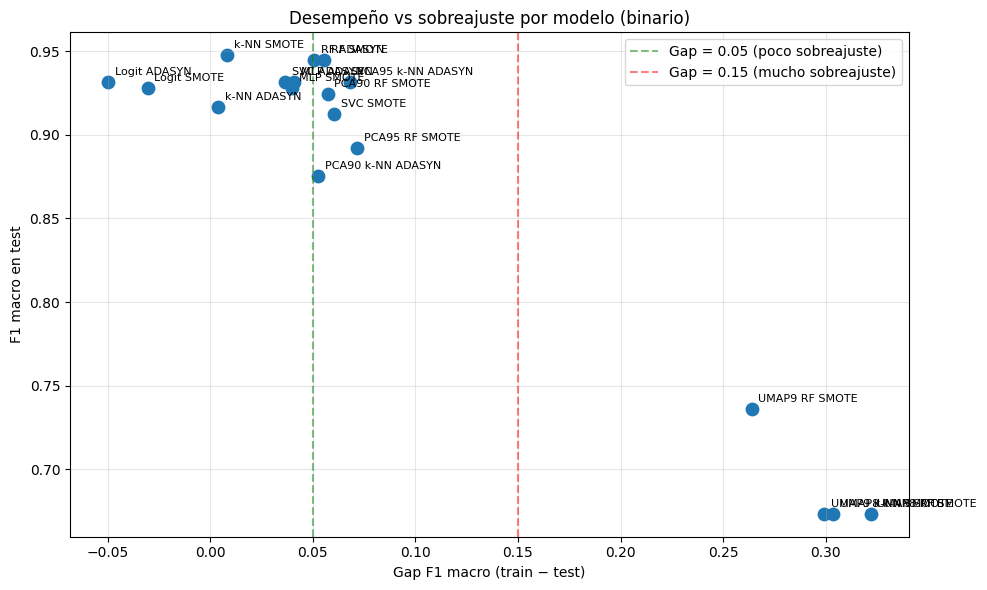

In [48]:
#--- Gráfica diagnóstica: F1 macro test vs Gap (train-test) (binario).
import os
os.makedirs("figs", exist_ok=True)
plt.figure(figsize=(10,6))
plt.scatter(tabla["Gap Train-Test"], tabla["F1 Macro Test"], s=80)
for i, row in tabla.iterrows():
    plt.annotate(row["Modelo"], (row["Gap Train-Test"], row["F1 Macro Test"]),
                 fontsize=8, xytext=(5,5), textcoords="offset points")
plt.axvline(0.05, color="green", linestyle="--", alpha=0.5, label="Gap = 0.05 (poco sobreajuste)")
plt.axvline(0.15, color="red", linestyle="--", alpha=0.5, label="Gap = 0.15 (mucho sobreajuste)")
plt.xlabel("Gap F1 macro (train − test)")
plt.ylabel("F1 macro en test")
plt.title("Desempeño vs sobreajuste por modelo (binario)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/bin_scatter_f1_gap.png", dpi=150, bbox_inches="tight")
plt.show()


### Curva de aprendizaje del mejor modelo (binario)


Curva de aprendizaje para: k-NN SMOTE


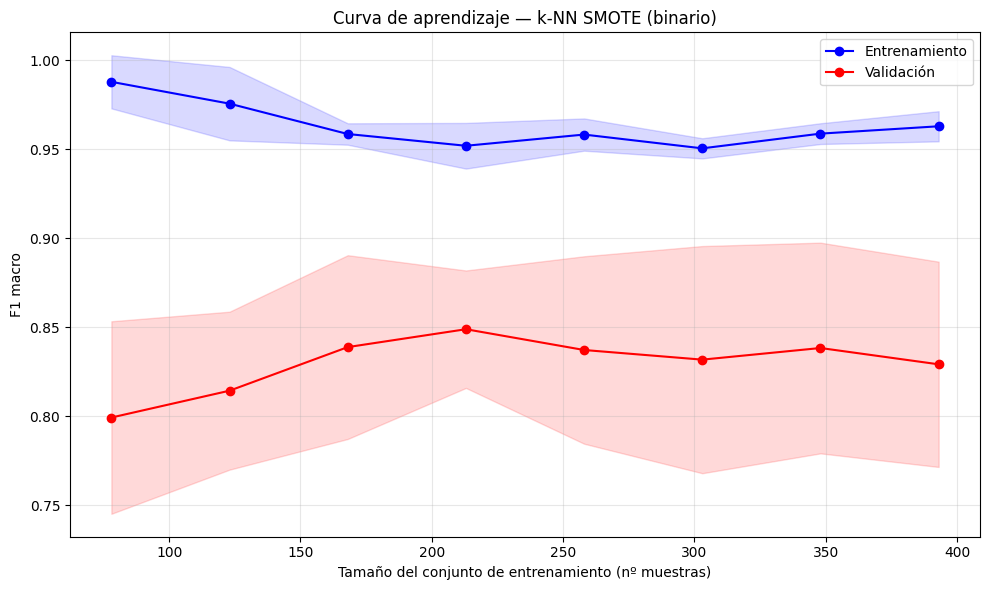

In [49]:
#--- Curva de aprendizaje del modelo con mejor F1 macro en test (binario).
os.makedirs("figs", exist_ok=True)
mejor_nombre = tabla.iloc[0]["Modelo"]
mejor_modelo = modelos[mejor_nombre].best_estimator_
print(f"Curva de aprendizaje para: {mejor_nombre}")

sizes, train_scores, val_scores = learning_curve(
    mejor_modelo, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=98),
    scoring="f1_macro",
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1, random_state=98, error_score=0.0)

train_mean = train_scores.mean(axis=1); train_std = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1);   val_std   = val_scores.std(axis=1)

plt.figure(figsize=(10,6))
plt.plot(sizes, train_mean, "o-", color="blue", label="Entrenamiento")
plt.fill_between(sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color="blue")
plt.plot(sizes, val_mean, "o-", color="red", label="Validación")
plt.fill_between(sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color="red")
plt.xlabel("Tamaño del conjunto de entrenamiento (nº muestras)")
plt.ylabel("F1 macro")
plt.title(f"Curva de aprendizaje — {mejor_nombre} (binario)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/bin_curva_aprendizaje.png", dpi=150, bbox_inches="tight")
plt.show()


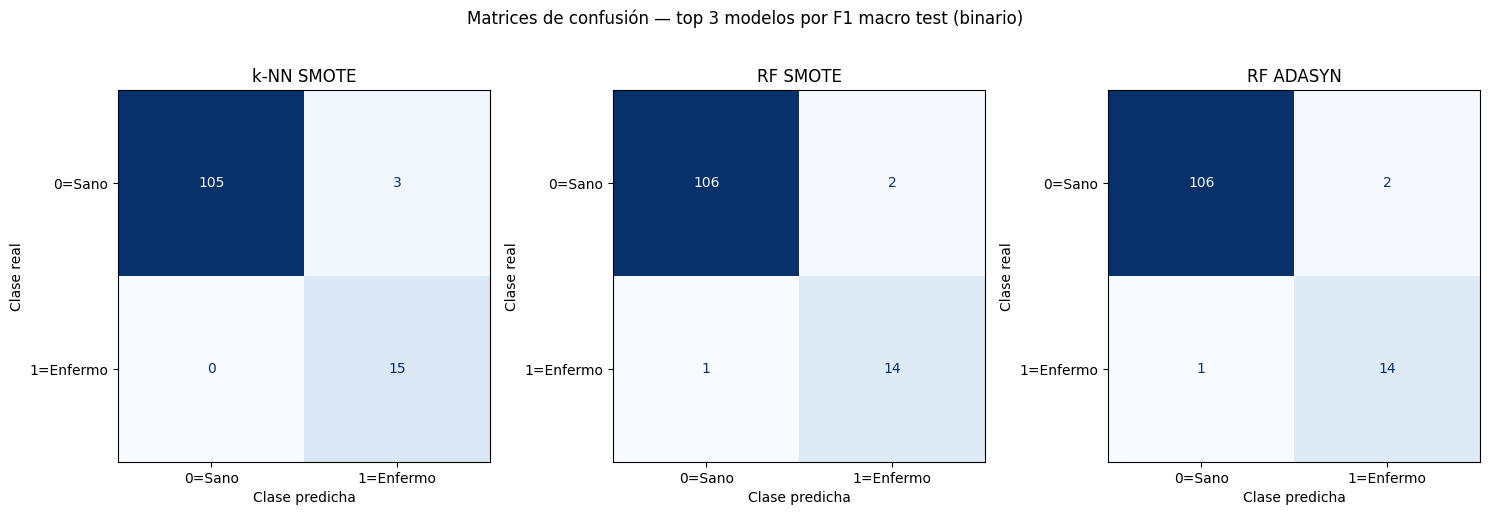

In [50]:
#--- Matrices de confusión de los 3 mejores modelos según F1 macro en test (binario).
os.makedirs("figs", exist_ok=True)
top3 = tabla.head(3)["Modelo"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, nombre in zip(axes, top3):
    modelo = modelos[nombre]
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases_binarias)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
fig.suptitle("Matrices de confusión — top 3 modelos por F1 macro test (binario)", y=1.02)
plt.tight_layout()
plt.savefig("figs/bin_matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


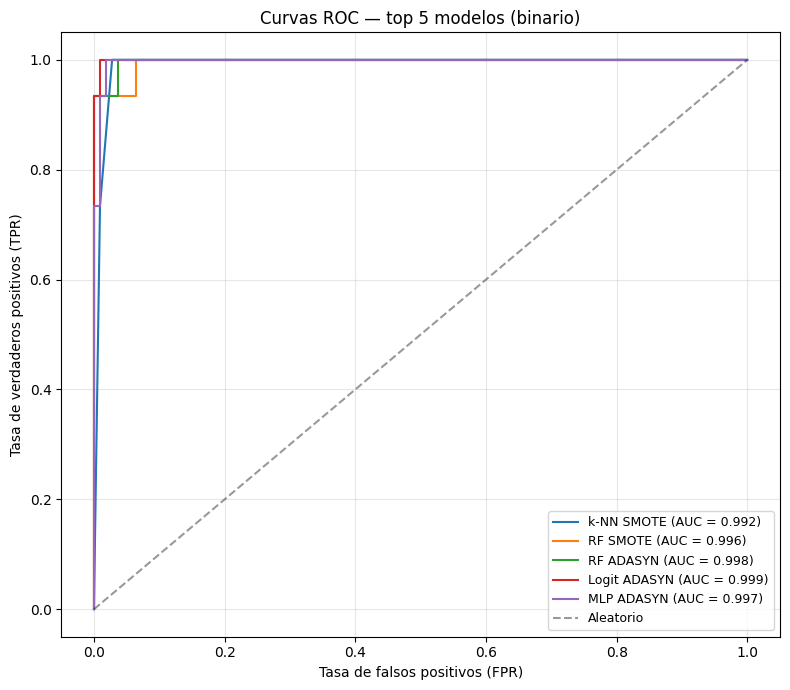

In [51]:
#--- Curvas ROC superpuestas para los 5 mejores modelos según F1 macro en test (binario).
os.makedirs("figs", exist_ok=True)
top5 = tabla.head(5)["Modelo"].tolist()
plt.figure(figsize=(8,7))
for nombre in top5:
    modelo = modelos[nombre]
    try:
        y_score = modelo.predict_proba(X_test)[:, 1]
    except Exception:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aleatorio")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curvas ROC — top 5 modelos (binario)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/bin_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### INTERVALOS DE CONFIANZA AL 95% (t-Student) sobre LAS MÉTRICAS DE DESEMPEÑO

Para cada modelo se ejecuta `cross_validate` con el `best_estimator_` ya obtenido del `GridSearchCV`,
usando el mismo objeto `cv` (StratifiedKFold 5) y un *scoring dict* multi-métrico.
A partir de los scores por fold se computa media, desviación estándar (muestral),
error estándar de la media y el intervalo de confianza al 95% con la t-Student
de $n-1$ grados de libertad ($n=5$).


In [53]:
#--- IC al 95% sobre las múltiples métricas de desempeño (binario).
#--- Se ejecuta cross_validate sobre el best_estimator_ de cada GridSearchCV
#--- reusando el mismo cv (StratifiedKFold 5) para obtener scores por fold
#--- de cada métrica. Luego se calcula la media, sd, SEM e IC95% con t-Student.

scoring_bin = {
    "F1 macro":          "f1_macro",
    "Balanced accuracy": "balanced_accuracy",
    "Accuracy":          "accuracy",
    "F1 Enfermo":        "f1",          # pos_label=1 por defecto (clase Enfermo)
    "AUC-ROC":           "roc_auc",
}

def ic_t(scores, alpha=0.05):
    """Devuelve (media, sd, sem, IC_inf, IC_sup) para un array de scores."""
    s = np.asarray(scores, dtype=float)
    s = s[~np.isnan(s)]
    n = len(s)
    if n < 2:
        return (float("nan"),) * 5
    media = float(s.mean())
    sd = float(s.std(ddof=1))
    sem = sd / np.sqrt(n)
    tc = float(stats.t.ppf(1 - alpha/2, df=n-1))
    margen = tc * sem
    return media, sd, sem, media - margen, media + margen

filas = []
for nombre, grid in modelos.items():
    print(f"Procesando: {nombre} ...")
    try:
        res = cross_validate(
            grid.best_estimator_, X_train, y_train,
            scoring=scoring_bin, cv=cv,
            n_jobs=-1, return_train_score=False, error_score=np.nan,
        )
    except Exception as e:
        print(f"  [!] error en {nombre}: {e}")
        continue
    for nombre_metrica, key in scoring_bin.items():
        scores = res[f"test_{nombre_metrica}"]
        media, sd, sem, li, ls = ic_t(scores)
        filas.append({
            "Modelo": nombre,
            "Métrica": nombre_metrica,
            "Media (CV)":  round(media, 4),
            "SD":          round(sd, 4),
            "SEM":         round(sem, 4),
            "IC 95% inf":  round(li, 4),
            "IC 95% sup":  round(ls, 4),
            "Amplitud IC": round(ls - li, 4),
            "n_folds":     int(np.sum(~np.isnan(scores))),
            "Reporte":     f"{media:.3f} [{li:.3f}, {ls:.3f}]",
        })

tabla_ic_long = pd.DataFrame(filas)
print("\n=== Tabla de IC (formato largo) ===")
display(tabla_ic_long)

#--- Pivot a formato ancho.
tabla_ic_wide = tabla_ic_long.pivot(index="Modelo", columns="Métrica", values="Reporte")
tabla_ic_wide = tabla_ic_wide.reindex(columns=list(scoring_bin.keys()))

orden = (tabla_ic_long[tabla_ic_long["Métrica"] == "F1 macro"]
         .sort_values("Media (CV)", ascending=False)["Modelo"].tolist())
tabla_ic_wide = tabla_ic_wide.reindex(orden)

print("\n=== Tabla de IC ===")
display(tabla_ic_wide)


Procesando: Logit SMOTE ...
Procesando: Logit ADASYN ...
Procesando: k-NN SMOTE ...
Procesando: k-NN ADASYN ...
Procesando: RF SMOTE ...
Procesando: RF ADASYN ...
Procesando: SVC SMOTE ...
Procesando: SVC ADASYN ...
Procesando: MLP SMOTE ...
Procesando: MLP ADASYN ...
Procesando: PCA90 RF SMOTE ...
Procesando: PCA95 RF SMOTE ...
Procesando: PCA90 k-NN ADASYN ...
Procesando: PCA95 k-NN ADASYN ...
Procesando: UMAP8 RF SMOTE ...
Procesando: UMAP9 RF SMOTE ...
Procesando: UMAP8 k-NN SMOTE ...
Procesando: UMAP9 k-NN SMOTE ...

=== Tabla de IC (formato largo) ===


,Modelo,Métrica,Media (CV),SD,SEM,IC 95% inf,IC 95% sup,Amplitud IC,n_folds,Reporte
0,Logit SMOTE,F1 macro,0.8771,0.0542,0.0243,0.8098,0.9445,0.1347,5,"0.877 [0.810, 0.944]"
1,Logit SMOTE,Balanced accuracy,0.8838,0.0664,0.0297,0.8013,0.9663,0.1649,5,"0.884 [0.801, 0.966]"
2,Logit SMOTE,Accuracy,0.9472,0.0217,0.0097,0.9203,0.9742,0.0539,5,"0.947 [0.920, 0.974]"
3,Logit SMOTE,F1 Enfermo,0.7844,0.0963,0.0431,0.6648,0.9039,0.2391,5,"0.784 [0.665, 0.904]"
4,Logit SMOTE,AUC-ROC,0.9233,0.0924,0.0413,0.8085,1.0381,0.2296,5,"0.923 [0.809, 1.038]"
...,...,...,...,...,...,...,...,...,...,...
85,UMAP9 k-NN SMOTE,F1 macro,0.7511,0.1116,0.0499,0.6126,0.8896,0.2771,5,"0.751 [0.613, 0.890]"
86,UMAP9 k-NN SMOTE,Balanced accuracy,0.7049,0.1103,0.0493,0.5679,0.8418,0.2738,5,"0.705 [0.568, 0.842]"
87,UMAP9 k-NN SMOTE,Accuracy,0.9228,0.0272,0.0122,0.8891,0.9566,0.0675,5,"0.923 [0.889, 0.957]"
88,UMAP9 k-NN SMOTE,F1 Enfermo,0.5444,0.2088,0.0934,0.2851,0.8037,0.5186,5,"0.544 [0.285, 0.804]"



=== Tabla de IC ===


Métrica,F1 macro,Balanced accuracy,Accuracy,F1 Enfermo,AUC-ROC
Modelo,,,,,
RF SMOTE,"0.936 [0.860, 1.012]","0.928 [0.833, 1.022]","0.974 [0.942, 1.005]","0.887 [0.752, 1.022]","0.982 [0.952, 1.012]"
RF ADASYN,"0.935 [0.867, 1.004]","0.935 [0.835, 1.035]","0.974 [0.948, 1.000]","0.886 [0.764, 1.008]","0.980 [0.945, 1.014]"
SVC SMOTE,"0.903 [0.838, 0.967]","0.911 [0.840, 0.983]","0.957 [0.929, 0.986]","0.829 [0.717, 0.942]","0.975 [0.955, 0.995]"
MLP SMOTE,"0.899 [0.829, 0.970]","0.897 [0.822, 0.971]","0.957 [0.928, 0.987]","0.823 [0.699, 0.948]","0.929 [0.821, 1.038]"
MLP ADASYN,"0.898 [0.836, 0.959]","0.897 [0.811, 0.983]","0.957 [0.933, 0.981]","0.820 [0.710, 0.929]","0.927 [0.825, 1.028]"
SVC ADASYN,"0.894 [0.828, 0.960]","0.909 [0.836, 0.982]","0.953 [0.924, 0.982]","0.816 [0.700, 0.931]","0.974 [0.953, 0.994]"
Logit SMOTE,"0.877 [0.810, 0.944]","0.884 [0.801, 0.966]","0.947 [0.920, 0.974]","0.784 [0.665, 0.904]","0.923 [0.809, 1.038]"
PCA90 k-NN ADASYN,"0.856 [0.784, 0.928]","0.864 [0.789, 0.938]","0.937 [0.904, 0.970]","0.748 [0.623, 0.874]","0.882 [0.830, 0.934]"
Logit ADASYN,"0.853 [0.800, 0.906]","0.889 [0.825, 0.953]","0.931 [0.907, 0.955]","0.746 [0.654, 0.838]","0.916 [0.806, 1.026]"
